# Random Forest — Polymarket ML

**DS-GA 1003 | NYU**  
Trains two Random Forest models on the Polymarket snapshot dataset:
- `rf_price_only` — baseline ML model using only `price_at_snapshot`
- `rf_full` — all 21 engineered features

Answers RQ1 (beat market baseline?), RQ2 (do engineered features add value?), RQ3 (which lifecycle stage?)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, roc_curve
from sklearn.calibration import calibration_curve

# GPU via cuML if available, otherwise sklearn
try:
    from cuml.ensemble import RandomForestClassifier
    import cupy as cp
    GPU = True
    print("cuML detected — training on GPU")
except ImportError:
    from sklearn.ensemble import RandomForestClassifier
    GPU = False
    print("cuML not found — falling back to sklearn CPU")

ROOT       = Path("../../")
DATA_PATH  = ROOT / "data" / "polymarket_ml_dataset.parquet"
ART_DIR    = Path("artifacts")
PRED_DIR   = Path("predictions")
ART_DIR.mkdir(exist_ok=True)
PRED_DIR.mkdir(exist_ok=True)

cuML not found — falling back to sklearn CPU


## 1. Load & Split

In [2]:
print("Loading parquet...")
df = pd.read_parquet(DATA_PATH)
print(f"Total rows: {len(df):,} | Columns: {df.shape[1]}")

train = df[df["split"] == "train"].reset_index(drop=True)
test  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train):,} rows | {train['market_id'].nunique():,} markets")
print(f"Test:  {len(test):,}  rows | {test['market_id'].nunique():,} markets")
print(f"Train YES rate: {train['outcome'].mean():.3f}")
print(f"Test  YES rate: {test['outcome'].mean():.3f}")

# Leakage check
overlap = set(train["market_id"]) & set(test["market_id"])
assert len(overlap) == 0, f"LEAKAGE: {len(overlap)} markets in both splits"
print("Leakage check passed")

Loading parquet...
Total rows: 4,078,109 | Columns: 27
Train: 3,268,545 rows | 17,073 markets
Test:  809,564  rows | 4,243 markets
Train YES rate: 0.171
Test  YES rate: 0.162
Leakage check passed


## 2. Feature Engineering

In [3]:
# Encode category
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train = train.copy()
test  = test.copy()
train["category_encoded"] = enc.fit_transform(train[["category"]]).astype(np.float32)
test["category_encoded"]  = enc.transform(test[["category"]]).astype(np.float32)
print("Categories:", enc.categories_[0].tolist())
assert len(enc.categories_[0]) >= 9, "Expected 9 categories - check parquet"

FEATURES_PRICE_ONLY = ["price_at_snapshot"]

FEATURES_FULL = [
    "price_at_snapshot", "price_deviation_from_half",
    "price_mean_7d",     "price_volatility_7d",  "price_min_7d",
    "price_max_7d",      "price_change_7d",       "price_range_7d",  "price_trend_7d",
    "price_mean_14d",    "price_volatility_14d",  "price_min_14d",
    "price_max_14d",     "price_change_14d",      "price_range_14d", "price_trend_14d",
    "pct_lifetime_elapsed", "days_before_close", "duration_days",
    "log_volume", "category_encoded",
]

TARGET = "outcome"

# Market-level 80/20 split within train: train_fit for RF, train_cal for isotonic calibration
rng = np.random.default_rng(42)
all_market_ids = train["market_id"].unique()
cal_ids = set(rng.choice(all_market_ids, size=int(0.2 * len(all_market_ids)), replace=False))

train_fit = train[~train["market_id"].isin(cal_ids)].reset_index(drop=True)
train_cal = train[ train["market_id"].isin(cal_ids)].reset_index(drop=True)

print(f"train_fit: {len(train_fit):,} rows | {train_fit['market_id'].nunique():,} markets")
print(f"train_cal: {len(train_cal):,} rows | {train_cal['market_id'].nunique():,} markets")

X_train_price = train_fit[FEATURES_PRICE_ONLY].values.astype(np.float32)
X_train_full  = train_fit[FEATURES_FULL].values.astype(np.float32)
y_train       = train_fit[TARGET].values.astype(np.int32)

X_cal_full    = train_cal[FEATURES_FULL].values.astype(np.float32)
y_cal         = train_cal[TARGET].values.astype(np.int32)

X_test_price  = test[FEATURES_PRICE_ONLY].values.astype(np.float32)
X_test_full   = test[FEATURES_FULL].values.astype(np.float32)
y_test        = test[TARGET].values.astype(np.int32)

sample_weights = compute_sample_weight("balanced", y_train).astype(np.float32)

print(f"X_train_full shape: {X_train_full.shape}")
print(f"Class weight ratio (NO:YES): {sample_weights[y_train==0].mean():.3f} : {sample_weights[y_train==1].mean():.3f}")


Categories: ['crypto', 'entertainment', 'finance', 'geopolitics', 'other', 'politics_global', 'politics_us', 'science_tech', 'sports']
train_fit: 2,630,081 rows | 13,659 markets
train_cal: 638,464 rows | 3,414 markets
X_train_full shape: (2630081, 21)
Class weight ratio (NO:YES): 0.604 : 2.894


## 3. Market Price Baseline

In [4]:
baseline_proba = test["price_at_snapshot"].values.clip(1e-6, 1 - 1e-6)

baseline_auc   = roc_auc_score(y_test, baseline_proba)
baseline_ll    = log_loss(y_test, baseline_proba)
baseline_brier = brier_score_loss(y_test, baseline_proba)

print("Market price baseline (test set):")
print(f"  AUC-ROC:     {baseline_auc:.4f}")
print(f"  Log-loss:    {baseline_ll:.4f}")
print(f"  Brier score: {baseline_brier:.4f}")
print()
print("This is the bar every model must beat.")

Market price baseline (test set):
  AUC-ROC:     0.9674
  Log-loss:    0.1633
  Brier score: 0.0478

This is the bar every model must beat.


## 4. Cross-Validation (Full Features)
5-fold CV grouped by `market_id` to prevent leakage across folds.

In [5]:
cv = StratifiedGroupKFold(n_splits=5)
groups = train_fit["market_id"].values

rf_params = dict(
    n_estimators=100,
    max_depth=16,
    random_state=42,
)
if not GPU:
    rf_params.update(dict(
        min_samples_leaf=50,
        max_features="sqrt",
        n_jobs=-1,
    ))

oof_aucs = []
print("Running 5-fold CV...")

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_full, y_train, groups=groups)):
    X_tr, X_val = X_train_full[tr_idx], X_train_full[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    sw_tr       = sample_weights[tr_idx]

    if GPU:
        X_tr  = cp.asarray(X_tr)
        y_tr  = cp.asarray(y_tr)
        sw_tr = cp.asarray(sw_tr)

    rf_cv = RandomForestClassifier(**rf_params)
    rf_cv.fit(X_tr, y_tr, sample_weight=sw_tr)

    if GPU:
        proba_val = cp.asnumpy(rf_cv.predict_proba(cp.asarray(X_val)))[:, 1]
    else:
        proba_val = rf_cv.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, proba_val)
    oof_aucs.append(fold_auc)
    print(f"  Fold {fold+1}: AUC-ROC = {fold_auc:.4f}  "
          f"| markets_val={len(np.unique(groups[val_idx]))}")

print(f"\nCV mean AUC-ROC: {np.mean(oof_aucs):.4f} ± {np.std(oof_aucs):.4f}")
print(f"Baseline:        {baseline_auc:.4f}")

Running 5-fold CV...
  Fold 1: AUC-ROC = 0.9655  | markets_val=2731
  Fold 2: AUC-ROC = 0.9611  | markets_val=2733
  Fold 3: AUC-ROC = 0.9670  | markets_val=2732
  Fold 4: AUC-ROC = 0.9663  | markets_val=2732
  Fold 5: AUC-ROC = 0.9698  | markets_val=2731

CV mean AUC-ROC: 0.9659 ± 0.0028
Baseline:        0.9674


## 5. Train Final Models
300 trees on full training set.

In [6]:
from sklearn.calibration import CalibratedClassifierCV

final_params = dict(
    n_estimators=300,
    max_depth=16,
    random_state=42,
)
if not GPU:
    final_params.update(dict(
        min_samples_leaf=50,
        max_features="sqrt",
        n_jobs=-1,
    ))

def to_gpu(arr):
    return cp.asarray(arr) if GPU else arr

def to_cpu(arr):
    return cp.asnumpy(arr) if GPU else arr

print("Training rf_price_only...")
rf_price_only = RandomForestClassifier(**final_params)
rf_price_only.fit(to_gpu(X_train_price), to_gpu(y_train), sample_weight=to_gpu(sample_weights))
joblib.dump(rf_price_only, ART_DIR / "rf_price_only.pkl")
print("  Saved -> artifacts/rf_price_only.pkl")

print("Training rf_full...")
rf_full = RandomForestClassifier(**final_params)
rf_full.fit(to_gpu(X_train_full), to_gpu(y_train), sample_weight=to_gpu(sample_weights))
joblib.dump(rf_full, ART_DIR / "rf_full.pkl")
print("  Saved -> artifacts/rf_full.pkl")

# Isotonic calibration on held-out calibration set
# cv="prefit" means the RF is already fit; we only learn the probability mapping
print("Calibrating with isotonic regression on train_cal...")
rf_full_cal = CalibratedClassifierCV(rf_full, method="isotonic", cv="prefit")
rf_full_cal.fit(X_cal_full, y_cal)
joblib.dump(rf_full_cal, ART_DIR / "rf_full_calibrated.pkl")
print("  Saved -> artifacts/rf_full_calibrated.pkl")


Training rf_price_only...
  Saved -> artifacts/rf_price_only.pkl
Training rf_full...
  Saved -> artifacts/rf_full.pkl
Calibrating with isotonic regression on train_cal...
  Saved -> artifacts/rf_full_calibrated.pkl


## 6. Test Set Evaluation

In [7]:
proba_price = to_cpu(rf_price_only.predict_proba(to_gpu(X_test_price)))[:, 1]
proba_full  = to_cpu(rf_full.predict_proba(to_gpu(X_test_full)))[:, 1]
proba_cal   = rf_full_cal.predict_proba(X_test_full)[:, 1]

results = {}
for label, proba in [("market_baseline",   baseline_proba),
                     ("rf_price_only",      proba_price),
                     ("rf_full",            proba_full),
                     ("rf_full_calibrated", proba_cal)]:
    results[label] = {
        "auc_roc":     round(roc_auc_score(y_test, proba), 4),
        "log_loss":    round(log_loss(y_test, proba.clip(1e-6, 1-1e-6)), 4),
        "brier_score": round(brier_score_loss(y_test, proba), 4),
    }

results_df = pd.DataFrame(results).T
results_df["delta_auc_vs_baseline"] = (results_df["auc_roc"]  - results_df.loc["market_baseline", "auc_roc"]).round(4)
results_df["delta_ll_vs_baseline"]  = (results_df["log_loss"] - results_df.loc["market_baseline", "log_loss"]).round(4)
print(results_df.to_string())


                    auc_roc  log_loss  brier_score  delta_auc_vs_baseline  delta_ll_vs_baseline
market_baseline      0.9674    0.1633       0.0478                 0.0000                0.0000
rf_price_only        0.9679    0.2264       0.0687                 0.0005                0.0631
rf_full              0.9688    0.1875       0.0559                 0.0014                0.0242
rf_full_calibrated   0.9687    0.1515       0.0442                 0.0013               -0.0118


## 7. ROC Curve

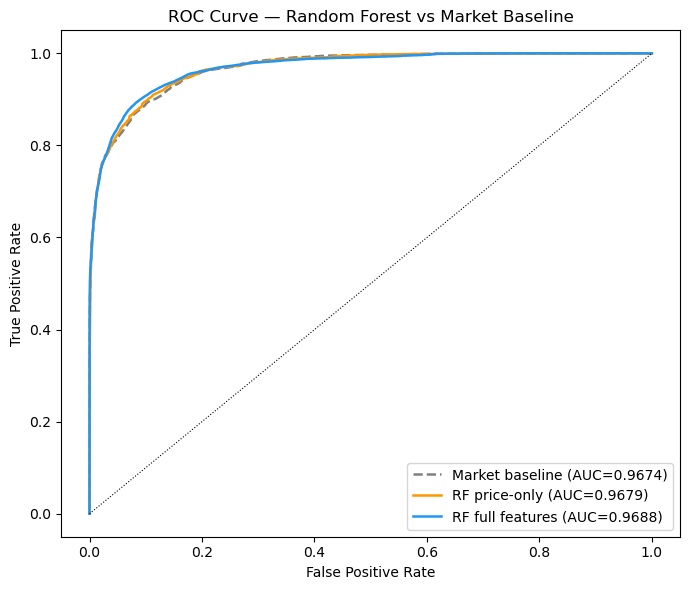

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

for label, proba, color, ls in [
    ("Market baseline", baseline_proba, "gray",     "--"),
    ("RF price-only",   proba_price,    "#FF9800",  "-"),
    ("RF full features",proba_full,     "#2196F3",  "-"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=1.8,
            label=f"{label} (AUC={auc:.4f})")

ax.plot([0,1],[0,1], "k:", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Random Forest vs Market Baseline")
ax.legend()
plt.tight_layout()
plt.savefig(ART_DIR / "roc_curve.png", dpi=150)
plt.show()

## 8. Calibration Curve

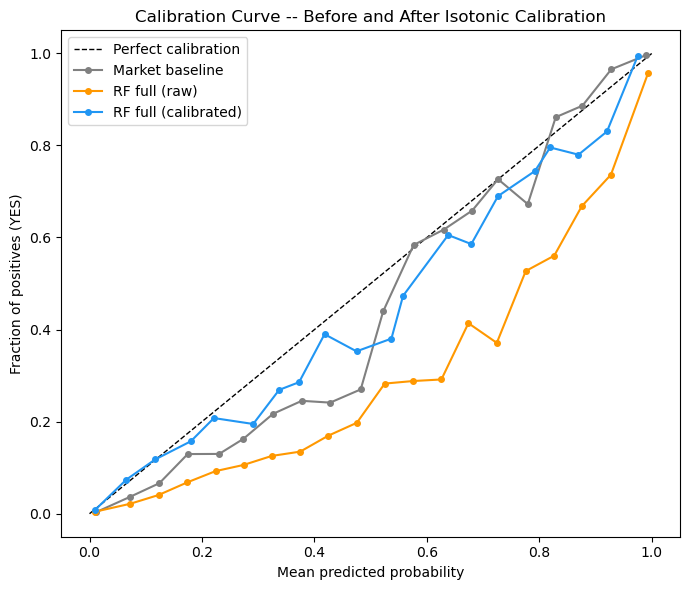

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1], "k--", linewidth=1, label="Perfect calibration")

for label, proba, color in [
    ("Market baseline",       baseline_proba, "gray"),
    ("RF full (raw)",         proba_full,     "#FF9800"),
    ("RF full (calibrated)",  proba_cal,      "#2196F3"),
]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=20)
    ax.plot(mean_pred, frac_pos, marker="o", markersize=4, color=color, label=label)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (YES)")
ax.set_title("Calibration Curve -- Before and After Isotonic Calibration")
ax.legend()
plt.tight_layout()
plt.savefig(ART_DIR / "calibration.png", dpi=150)
plt.show()


## 9. Feature Importance (RQ2)

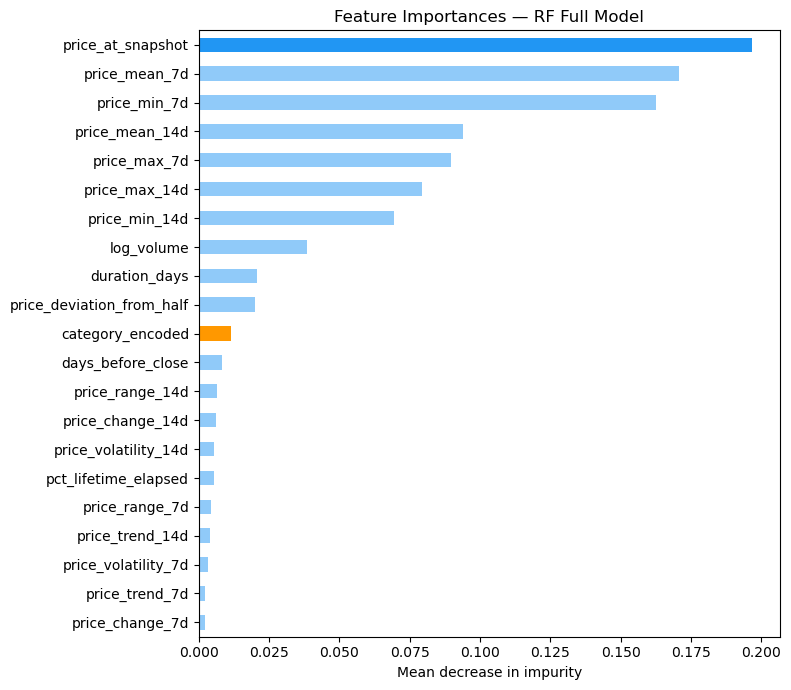


Top 10 features:
price_at_snapshot            0.1967
price_mean_7d                0.1707
price_min_7d                 0.1627
price_mean_14d               0.0940
price_max_7d                 0.0898
price_max_14d                0.0792
price_min_14d                0.0692
log_volume                   0.0386
duration_days                0.0207
price_deviation_from_half    0.0199
dtype: float64


In [10]:
if GPU:
    importances = cp.asnumpy(rf_full.feature_importances_)
else:
    importances = rf_full.feature_importances_

imp_series = pd.Series(importances, index=FEATURES_FULL).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#2196F3" if f == "price_at_snapshot" else
          "#FF9800" if f == "category_encoded" else "#90CAF9"
          for f in imp_series.index]
imp_series.plot.barh(ax=ax, color=colors)
ax.set_title("Feature Importances — RF Full Model")
ax.set_xlabel("Mean decrease in impurity")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(ART_DIR / "feature_importance.png", dpi=150)
plt.show()

print("\nTop 10 features:")
print(imp_series.sort_values(ascending=False).head(10).round(4))

## 10. Lifecycle AUC by Stage (RQ3)
Where in a market's lifecycle do engineered features add the most value over the raw price?

Lifecycle stage  Snapshots  RF AUC  RF Cal AUC  Baseline AUC  Delta (cal)
  Early (0-33%)     226832  0.9471      0.9469        0.9426       0.0043
   Mid (33-67%)     346681  0.9660      0.9659        0.9636       0.0023
 Late (67-100%)     236051  0.9870      0.9870        0.9883      -0.0013


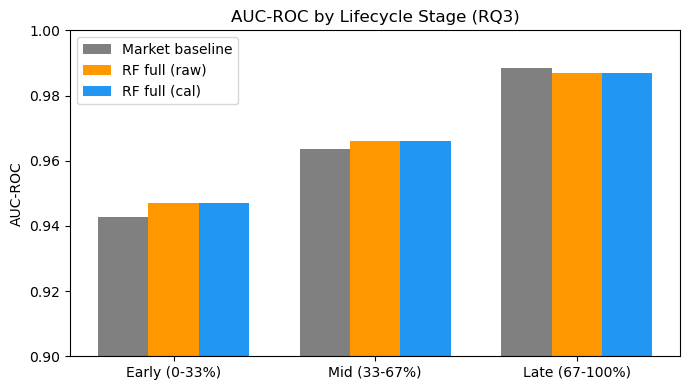

In [11]:
lc = test[["outcome", "pct_lifetime_elapsed", "price_at_snapshot"]].copy()
lc["proba_full"] = proba_full
lc["proba_cal"]  = proba_cal

bins   = [0, 0.33, 0.67, 1.001]
labels = ["Early (0-33%)", "Mid (33-67%)", "Late (67-100%)"]
lc["bucket"] = pd.cut(lc["pct_lifetime_elapsed"], bins=bins, labels=labels)

rows = []
for bucket, grp in lc.groupby("bucket", observed=True):
    if grp["outcome"].nunique() < 2:
        continue
    rows.append({
        "Lifecycle stage": bucket,
        "Snapshots":       len(grp),
        "RF AUC":          round(roc_auc_score(grp["outcome"], grp["proba_full"]), 4),
        "RF Cal AUC":      round(roc_auc_score(grp["outcome"], grp["proba_cal"]), 4),
        "Baseline AUC":    round(roc_auc_score(grp["outcome"], grp["price_at_snapshot"]), 4),
        "Delta (cal)":     round(roc_auc_score(grp["outcome"], grp["proba_cal"]) -
                                 roc_auc_score(grp["outcome"], grp["price_at_snapshot"]), 4),
    })

lc_df = pd.DataFrame(rows)
print(lc_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(lc_df))
w = 0.25
ax.bar(x - w,  lc_df["Baseline AUC"], w, label="Market baseline", color="gray")
ax.bar(x,      lc_df["RF AUC"],       w, label="RF full (raw)",   color="#FF9800")
ax.bar(x + w,  lc_df["RF Cal AUC"],   w, label="RF full (cal)",   color="#2196F3")
ax.set_xticks(x)
ax.set_xticklabels(lc_df["Lifecycle stage"])
ax.set_ylabel("AUC-ROC")
ax.set_title("AUC-ROC by Lifecycle Stage (RQ3)")
ax.legend()
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.savefig(ART_DIR / "lifecycle_auc.png", dpi=150)
plt.show()


## 11. Save Predictions

In [12]:
preds_df = pd.DataFrame({
    "market_id":             test["market_id"].values,
    "snapshot_timestamp":    test["snapshot_timestamp"].values,
    "outcome":               y_test,
    "proba_price_only":      proba_price.round(6),
    "proba_full":            proba_full.round(6),
    "proba_full_calibrated": proba_cal.round(6),
})

preds_df.to_csv(PRED_DIR / "test_predictions.csv", index=False)
print(f"Saved {len(preds_df):,} rows -> predictions/test_predictions.csv")
preds_df.head(3)


Saved 809,564 rows -> predictions/test_predictions.csv


,market_id,snapshot_timestamp,outcome,proba_price_only,proba_full,proba_full_calibrated
0,0xdbdc9d6ae20cd847d8b7728de6ce7a788dfccadde77a...,2025-09-13 21:57:39.995020+00:00,1,0.516320,0.402415,0.161710
1,0xdbdc9d6ae20cd847d8b7728de6ce7a788dfccadde77a...,2025-09-14 09:57:39.995020+00:00,1,0.469873,0.405480,0.194977
2,0xdbdc9d6ae20cd847d8b7728de6ce7a788dfccadde77a...,2025-09-14 21:57:39.995020+00:00,1,0.483997,0.392238,0.159262


## 12. Summary

In [13]:
print("=" * 60)
print("RANDOM FOREST -- RESULTS SUMMARY")
print("=" * 60)
print(results_df[["auc_roc", "log_loss", "brier_score",
                   "delta_auc_vs_baseline", "delta_ll_vs_baseline"]].to_string())
print()
print(f"CV AUC-ROC (5-fold, full features): {np.mean(oof_aucs):.4f} +/- {np.std(oof_aucs):.4f}")
print()
print("Artifacts saved:")
for f in sorted(ART_DIR.iterdir()):
    if not f.name.startswith("."):
        print(f"  {f}")
print(f"  {PRED_DIR}/test_predictions.csv")


RANDOM FOREST -- RESULTS SUMMARY
                    auc_roc  log_loss  brier_score  delta_auc_vs_baseline  delta_ll_vs_baseline
market_baseline      0.9674    0.1633       0.0478                 0.0000                0.0000
rf_price_only        0.9679    0.2264       0.0687                 0.0005                0.0631
rf_full              0.9688    0.1875       0.0559                 0.0014                0.0242
rf_full_calibrated   0.9687    0.1515       0.0442                 0.0013               -0.0118

CV AUC-ROC (5-fold, full features): 0.9659 +/- 0.0028

Artifacts saved:
  artifacts\calibration.png
  artifacts\feature_importance.png
  artifacts\lifecycle_auc.png
  artifacts\rf_full.pkl
  artifacts\rf_full_calibrated.pkl
  artifacts\rf_price_only.pkl
  artifacts\roc_curve.png
  predictions/test_predictions.csv
